# Notebook 04 (v2): Land Value Decomposition

In [45]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from pathlib import Path
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

In [46]:
# Load data
df_train = pd.read_parquet("../data/processed/train_split.parquet")
df_val = pd.read_parquet("../data/processed/val_split.parquet")
df_test = pd.read_parquet("../data/processed/test_split.parquet")
assessment = pd.read_parquet("../data/processed/assessment_clean.parquet")
land_rates = pd.read_parquet("../data/raw/land_nbhd_rate_data.parquet")
with open("../data/processed/feature_config.json") as f:
    config = json.load(f)
TARGET = config["target_col"]
CLASS_COL = config["class_col"]
# Load the full AVM for total value predictions
lgb_full_model = lgb.Booster(model_file="../outputs/models/lgb_avm_model.txt")
print(f"Training: {df_train.shape}")
print(f"Assessment: {assessment.shape}")

Training: (324088, 209)
Assessment: (1100150, 199)


## 1. Understand the CCAO Assessed Land Values (Benchmark)

Before building our model, let's see what the Assessor's own land
values look like. These will serve as our validation benchmark.

In [47]:
# === Find the CCAO's land/building assessed value columns ===
land_bldg_cols = [c for c in assessment.columns 
                  if any(x in c.lower() for x in ["_land", "_bldg"])
                  and "meta" in c.lower()]
print("=== CCAO Land/Building Assessed Value Columns ===")
for col in sorted(land_bldg_cols):
    n_valid = assessment[col].notna().sum()
    if n_valid > 0:
        print(f"  {col}: {n_valid:,} non-null, "
              f"mean={assessment[col].mean():.0f}, "
              f"median={assessment[col].median():.0f}")

=== CCAO Land/Building Assessed Value Columns ===
  meta_1yr_pri_board_bldg: 1,099,480 non-null, mean=25210, median=20500
  meta_1yr_pri_board_land: 1,099,480 non-null, mean=8008, median=5499
  meta_2yr_pri_board_bldg: 1,097,970 non-null, mean=23456, median=18304
  meta_2yr_pri_board_land: 1,097,970 non-null, mean=7721, median=5148
  meta_board_bldg: 166,891 non-null, mean=33795, median=25714
  meta_board_land: 166,891 non-null, mean=9711, median=6875
  meta_certified_bldg: 1,100,150 non-null, mean=27516, median=22000
  meta_certified_land: 1,100,150 non-null, mean=8512, median=5639
  meta_mailed_bldg: 1,100,150 non-null, mean=27753, median=22030
  meta_mailed_land: 1,100,150 non-null, mean=8518, median=5640
  meta_pin_num_landlines: 1,100,145 non-null, mean=1, median=1


In [48]:
LAND_AV_COL = "meta_certified_land"
BLDG_AV_COL = "meta_certified_bldg"

print(f"\nUsing CCAO assessed values:")
print(f"  Land column: {LAND_AV_COL}")
print(f"  Building column: {BLDG_AV_COL}")

# Compute the CCAO's own site-to-total ratio (at assessed value level)
ccao_total = assessment[LAND_AV_COL] + assessment[BLDG_AV_COL]
ccao_land_ratio = assessment[LAND_AV_COL] / ccao_total.replace(0, np.nan)

print(f"\n=== CCAO Assessed Land-to-Total Ratio ===")
print(ccao_land_ratio.describe())
print(f"\nThis is our TARGET range for the hedonic model.")


Using CCAO assessed values:
  Land column: meta_certified_land
  Building column: meta_certified_bldg

=== CCAO Assessed Land-to-Total Ratio ===
count   1100150.00
mean          0.23
std           0.11
min           0.00
25%           0.16
50%           0.21
75%           0.28
max           1.00
dtype: float64

This is our TARGET range for the hedonic model.


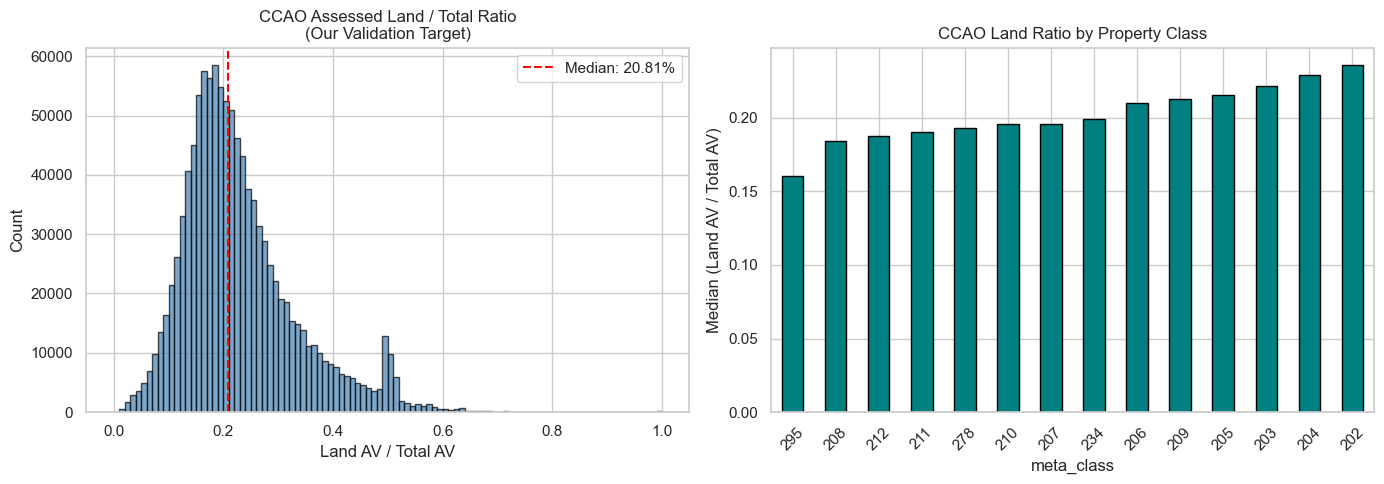

In [49]:
# Visualize the CCAO benchmark
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = ccao_land_ratio.dropna()
valid = valid[(valid >= 0) & (valid <= 1)]

axes[0].hist(valid, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(valid.median(), color="red", linestyle="--",
                label=f"Median: {valid.median():.2%}")
axes[0].set_title("CCAO Assessed Land / Total Ratio\n(Our Validation Target)")
axes[0].set_xlabel("Land AV / Total AV")
axes[0].set_ylabel("Count")
axes[0].legend()

# By property class
assessment["ccao_land_ratio"] = ccao_land_ratio
class_ratios = assessment.groupby(CLASS_COL)["ccao_land_ratio"].median().sort_values()
class_ratios.plot(kind="bar", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("CCAO Land Ratio by Property Class")
axes[1].set_ylabel("Median (Land AV / Total AV)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/04v2_ccao_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Explore the CCAO Land Rate Data

The `land_nbhd_rate_data` file contains fixed $/sqft land rates by
assessor neighborhood. This is another benchmark.

In [50]:
print("=== Land Neighborhood Rate Data ===")
print(f"Shape: {land_rates.shape}")
print(f"Columns: {land_rates.columns.tolist()}")
print()
print(land_rates.head(20))
print()
print(land_rates.describe())

=== Land Neighborhood Rate Data ===
Shape: (5040, 3)
Columns: ['meta_nbhd', 'meta_class', 'land_rate_per_sqft']

   meta_nbhd meta_class  land_rate_per_sqft
0      10011        202                6.00
1      10011        203                6.00
2      10011        204                6.00
3      10011        205                6.00
4      10011        206                6.00
5      10011        207                6.00
6      10011        208                6.00
7      10011        209                6.00
8      10011        210                6.00
9      10011        211                6.00
10     10011        212                6.00
11     10011        218                6.00
12     10011        219                6.00
13     10011        234                6.00
14     10011        278                6.00
15     10011        295                6.00
16     10011        299                6.00
17     10011        399                6.00
18     10012        202               12.00
19     

In [51]:
# Try to join land rates to assessment data for a simple land value estimate
# The join key is likely neighborhood code + class
rate_col_candidates = [c for c in land_rates.columns if "rate" in c.lower()]
nbhd_col_candidates = [c for c in land_rates.columns if "nbhd" in c.lower() or "neighborhood" in c.lower()]
print(f"Rate columns: {rate_col_candidates}")
print(f"Neighborhood columns: {nbhd_col_candidates}")

Rate columns: ['land_rate_per_sqft']
Neighborhood columns: ['meta_nbhd']


## 3. Define Constrained Land-Only Feature Sets

We test THREE levels of feature restriction to find the sweet spot
between capturing location value and leaking improvement information.

In [52]:
# === TIER 1: Ultra-constrained (physical land + raw coordinates only) ===
# Only features that are intrinsic to the land parcel itself
TIER1_FEATURES = [
    # Physical lot
    "char_land_sf",
    "feat_log_land_sf",
    "feat_large_lot",
    
    # Raw spatial coordinates (smooth gradients, no memorization)
    "loc_latitude",
    "loc_longitude",
    
    # Parcel geometry
    "shp_parcel_centroid_dist_ft_sd",
    "shp_parcel_edge_len_ft_sd",
    "shp_parcel_interior_angle_sd",
    "shp_parcel_mrr_area_ratio",
    "shp_parcel_mrr_side_ratio",
    "shp_parcel_num_vertices",
    
    # Environmental (inherent to the land)
    "loc_env_flood_fs_factor",
]
# === TIER 2: Moderate (Tier 1 + continuous proximity features) ===
# Adds distance-based features that describe accessibility/amenities
# but NOT categorical identifiers
TIER2_FEATURES = TIER1_FEATURES + [
    # Proximity (continuous, distance-based)
    "prox_lake_michigan_dist_ft",
    "prox_nearest_cta_stop_dist_ft",
    "prox_nearest_metra_stop_dist_ft",
    "prox_nearest_park_dist_ft",
    "prox_nearest_hospital_dist_ft",
    "prox_nearest_water_dist_ft",
    "prox_nearest_golf_course_dist_ft",
    "prox_nearest_railroad_dist_ft",
    "prox_nearest_road_highway_dist_ft",
    "prox_nearest_vacant_land_dist_ft",
    "prox_nearest_university_dist_ft",
    "prox_nearest_bike_trail_dist_ft",
    "prox_nearest_cemetery_dist_ft",
    "prox_nearest_stadium_dist_ft",
    "prox_airport_dnl_total",
    "prox_num_pin_in_half_mile",
    "prox_num_bus_stop_in_half_mile",
    "prox_avg_school_rating_in_half_mile",
    
    # Walkability (continuous score, not categorical)
    "loc_access_cmap_walk_total_score",
    "loc_access_cmap_walk_nta_score",
]
# === TIER 3: Moderate+ (Tier 2 + select ACS economic indicators) ===
# Adds neighborhood economic context but NOT housing stock indicators
TIER3_FEATURES = TIER2_FEATURES + [
    # Economic indicators (describe area wealth, not building quality)
    "acs5_median_income_household_past_year",
    "acs5_median_income_per_capita_past_year",
    "acs5_percent_income_below_poverty_level",
    "acs5_percent_employment_unemployed",
    "acs5_percent_education_bachelor",
    "acs5_percent_education_graduate",
    "acs5_percent_age_children",
    "acs5_percent_age_senior",
    "acs5_percent_household_family_married",
    "acs5_percent_household_nonfamily_alone",
    
    # Tax rate (determined by location/jurisdiction)
    "other_tax_bill_rate",
]
# EXCLUDED from ALL tiers (the key fix):
# - loc_school_elementary_district_geoid   (categorical, too powerful)
# - loc_school_secondary_district_geoid    (categorical, too powerful)
# - loc_census_tract_geoid                 (categorical, too powerful)
# - loc_tax_municipality_name              (categorical, too powerful)
# - meta_nbhd_code                         (categorical, too powerful)
# - meta_township_code                     (categorical, too powerful)
# - acs5_median_household_renter_occupied_gross_rent  (reflects building quality)
# - acs5_median_household_owner_occupied_value        (DIRECTLY reflects improvements)
# - acs5_median_household_total_occupied_year_built   (reflects building stock age)
# - acs5_percent_household_owner_occupied             (reflects housing type mix)
# Filter to columns that exist
TIER1_FEATURES = [c for c in TIER1_FEATURES if c in df_train.columns]
TIER2_FEATURES = [c for c in TIER2_FEATURES if c in df_train.columns]
TIER3_FEATURES = [c for c in TIER3_FEATURES if c in df_train.columns]
print(f"Tier 1 (Ultra-constrained):  {len(TIER1_FEATURES)} features")
print(f"Tier 2 (Moderate):           {len(TIER2_FEATURES)} features")
print(f"Tier 3 (Moderate+):          {len(TIER3_FEATURES)} features")
# Also add time features for training
TIME_FEATS = [c for c in config.get("time_features", []) if c in df_train.columns]
print(f"Time features:               {len(TIME_FEATS)} (added during training only)")

Tier 1 (Ultra-constrained):  12 features
Tier 2 (Moderate):           32 features
Tier 3 (Moderate+):          43 features
Time features:               8 (added during training only)


## 4. Train All Three Land-Only Models

In [53]:
def train_land_model(features, tier_name, df_train, df_val, target, time_feats):
    """Train a constrained land-only LightGBM model."""
    
    train_feats = features + time_feats
    train_feats = [c for c in train_feats if c in df_train.columns]
    
    # ALL features are numeric in the constrained model (no categoricals!)
    # This is intentional — we dropped all categorical location identifiers
    # Filter out any non-numeric columns (e.g. string time features like quarter)
    numeric_cols = df_train[train_feats].select_dtypes(include=["number", "bool"]).columns.tolist()
    train_feats = [c for c in train_feats if c in numeric_cols]
    
    lgb_train = lgb.Dataset(
        df_train[train_feats], label=df_train[target], free_raw_data=False,
    )
    lgb_val = lgb.Dataset(
        df_val[train_feats], label=df_val[target],
        reference=lgb_train, free_raw_data=False,
    )
    
    # More regularized than the full AVM — we WANT this model to
    # underfit on improvement-related variance
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": 0.05,
        "num_leaves": 128,          # Lower than full AVM (512) — less complex
        "min_data_in_leaf": 200,    # Higher — more regularization
        "feature_fraction": 0.8,    # Higher — fewer features to choose from
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "lambda_l1": 1.0,           # Stronger L1
        "lambda_l2": 5.0,           # Stronger L2
        "min_gain_to_split": 0.1,   # Higher threshold to split
        "verbose": -1,
        "n_jobs": -1,
        "seed": 42,
    }
    
    print(f"\n{'='*60}")
    print(f"  Training {tier_name} ({len(train_feats)} features)")
    print(f"{'='*60}")
    
    model = lgb.train(
        params, lgb_train, num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=200),
        ],
    )
    
    print(f"Best iteration: {model.best_iteration}")
    return model, train_feats

# Train all three tiers
models = {}
feature_sets = {}
for tier_name, tier_features in [
    ("Tier 1: Physical+Coords", TIER1_FEATURES),
    ("Tier 2: +Proximity", TIER2_FEATURES),
    ("Tier 3: +ACS Economic", TIER3_FEATURES),
]:
    model, feats = train_land_model(
        tier_features, tier_name, df_train, df_val, TARGET, TIME_FEATS
    )
    models[tier_name] = model
    feature_sets[tier_name] = feats


  Training Tier 1: Physical+Coords (19 features)
Training until validation scores don't improve for 50 rounds
[200]	train's rmse: 130587	valid's rmse: 157327
[400]	train's rmse: 125239	valid's rmse: 155603
[600]	train's rmse: 121457	valid's rmse: 155038
Early stopping, best iteration is:
[656]	train's rmse: 120557	valid's rmse: 154933
Best iteration: 656

  Training Tier 2: +Proximity (39 features)
Training until validation scores don't improve for 50 rounds
[200]	train's rmse: 124242	valid's rmse: 153806
[400]	train's rmse: 117618	valid's rmse: 151680
[600]	train's rmse: 112679	valid's rmse: 151001
[800]	train's rmse: 108582	valid's rmse: 150409
Early stopping, best iteration is:
[835]	train's rmse: 107926	valid's rmse: 150329
Best iteration: 835

  Training Tier 3: +ACS Economic (50 features)
Training until validation scores don't improve for 50 rounds
[200]	train's rmse: 123420	valid's rmse: 154740
[400]	train's rmse: 115969	valid's rmse: 152984
[600]	train's rmse: 110585	valid's r

## 5. Evaluate Land-Only Models on Test Set

In [54]:
y_test = df_test[TARGET]
print("\n" + "=" * 80)
print("  LAND-ONLY MODEL EVALUATION (Test Set)")
print("=" * 80)
tier_results = {}
for tier_name, model in models.items():
    feats = feature_sets[tier_name]
    preds = model.predict(df_test[feats])
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    
    tier_results[tier_name] = {
        "RMSE": rmse, "R2": r2, "MAPE": mape, "predictions": preds,
    }
    
    print(f"\n--- {tier_name} ---")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAPE: {mape:.2%}")
# Compare to full AVM
full_feats = lgb_full_model.feature_name()
full_feats_available = [c for c in full_feats if c in df_test.columns]
# Encode all non-numeric columns as integer codes, then predict with numpy
df_test_copy = df_test[full_feats_available].copy()
for col in df_test_copy.columns:
    if not pd.api.types.is_numeric_dtype(df_test_copy[col]):
        df_test_copy[col] = df_test_copy[col].astype("category").cat.codes
full_preds = lgb_full_model.predict(df_test_copy.values)
full_r2 = r2_score(y_test, full_preds)
print(f"\n--- Full AVM (reference) ---")
print(f"  R2:   {full_r2:.4f}")
print(f"\n=== R2 GAP (Full AVM - Land Model) ===")
for tier_name, res in tier_results.items():
    gap = full_r2 - res["R2"]
    print(f"  {tier_name}: {gap:.4f}")
    print(f"    -> Land model explains {100*res['R2']/full_r2:.1f}% of what the full model does")
    print(f"    -> The remaining {100*gap/full_r2:.1f}% is improvement-driven value")


  LAND-ONLY MODEL EVALUATION (Test Set)

--- Tier 1: Physical+Coords ---
  RMSE: $167,027
  R2:   0.6729
  MAPE: 36.82%

--- Tier 2: +Proximity ---
  RMSE: $162,004
  R2:   0.6923
  MAPE: 35.37%

--- Tier 3: +ACS Economic ---
  RMSE: $162,257
  R2:   0.6914
  MAPE: 36.36%

--- Full AVM (reference) ---
  R2:   0.8293

=== R2 GAP (Full AVM - Land Model) ===
  Tier 1: Physical+Coords: 0.1564
    -> Land model explains 81.1% of what the full model does
    -> The remaining 18.9% is improvement-driven value
  Tier 2: +Proximity: 0.1370
    -> Land model explains 83.5% of what the full model does
    -> The remaining 16.5% is improvement-driven value
  Tier 3: +ACS Economic: 0.1380
    -> Land model explains 83.4% of what the full model does
    -> The remaining 16.6% is improvement-driven value


## 6. Decompose Values for All Assessment Properties

In [55]:
# Predict total market values using full AVM
assess_copy = assessment[full_feats_available].copy()
for col in assess_copy.columns:
    if not pd.api.types.is_numeric_dtype(assess_copy[col]):
        assess_copy[col] = assess_copy[col].astype("category").cat.codes
assessment["pred_total_value"] = lgb_full_model.predict(assess_copy.values)
# Predict site values for each tier
for tier_name, model in models.items():
    feats = feature_sets[tier_name]
    # For assessment data, set time features to assessment date
    assess_pred = assessment.copy()
    for col in TIME_FEATS:
        if col not in assess_pred.columns:
            if "year" in col:
                assess_pred[col] = 2025
            elif "day_of_year" in col:
                assess_pred[col] = 1
            elif "day_of_week" in col:
                assess_pred[col] = 3
            elif "day_of_month" in col:
                assess_pred[col] = 1
            elif "sale_day" in col and "of" not in col:
                assess_pred[col] = 10227
            elif "post_covid" in col:
                assess_pred[col] = True
            elif "quarter" in col:
                assess_pred[col] = "Q1"
            elif "month" in col:
                assess_pred[col] = "Jan"
            else:
                assess_pred[col] = 0
    
    feats_available = [c for c in feats if c in assess_pred.columns]
    site_preds = model.predict(assess_pred[feats_available])
    
    safe_name = tier_name.replace(":", "").replace(" ", "_").replace("+", "plus")
    assessment[f"pred_site_{safe_name}"] = site_preds
print("Site value predictions added for all tiers.")
print(f"Assessment columns now: {assessment.shape[1]}")

Site value predictions added for all tiers.
Assessment columns now: 204


## 7. Compare Decomposition Across Tiers

Site value prediction columns: ['pred_site_Tier_1_PhysicalplusCoords', 'pred_site_Tier_2_plusProximity', 'pred_site_Tier_3_plusACS_Economic']


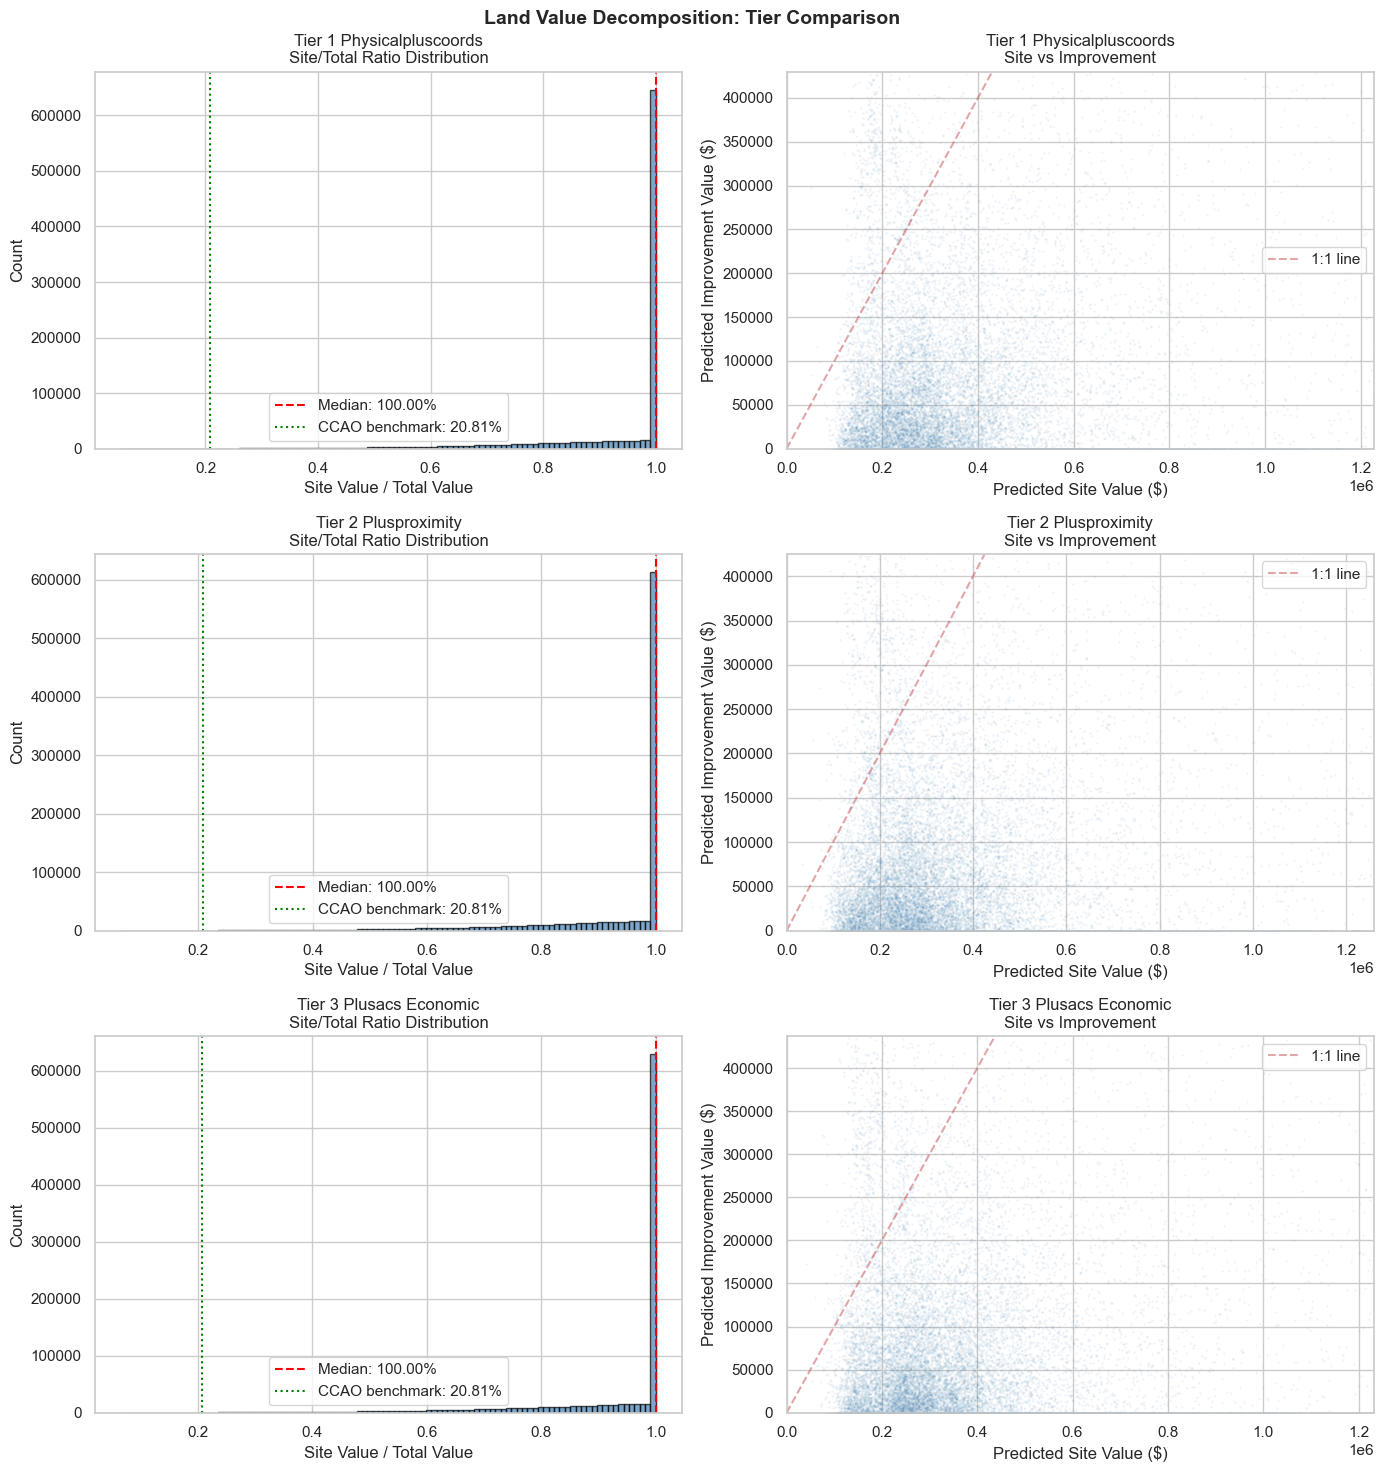

In [56]:
site_cols = [c for c in assessment.columns if c.startswith("pred_site_")]
print("Site value prediction columns:", site_cols)
fig, axes = plt.subplots(len(site_cols), 2, figsize=(14, 5 * len(site_cols)))
if len(site_cols) == 1:
    axes = axes.reshape(1, -1)
for i, site_col in enumerate(site_cols):
    tier_label = site_col.replace("pred_site_", "").replace("_", " ").title()
    
    # Compute improvement value and ratio
    imp_value = (assessment["pred_total_value"] - assessment[site_col]).clip(lower=0)
    site_ratio = assessment[site_col] / assessment["pred_total_value"].replace(0, np.nan)
    site_ratio = site_ratio.clip(0, 1)
    
    # Left: Distribution of site-to-total ratio
    ax = axes[i, 0]
    valid = site_ratio.dropna()
    ax.hist(valid, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
    ax.axvline(valid.median(), color="red", linestyle="--",
               label=f"Median: {valid.median():.2%}")
    
    # Add CCAO benchmark if available
    if LAND_AV_COL and "ccao_land_ratio" in assessment.columns:
        ccao_med = assessment["ccao_land_ratio"].median()
        ax.axvline(ccao_med, color="green", linestyle=":",
                   label=f"CCAO benchmark: {ccao_med:.2%}")
    
    ax.set_title(f"{tier_label}\nSite/Total Ratio Distribution")
    ax.set_xlabel("Site Value / Total Value")
    ax.set_ylabel("Count")
    ax.legend()
    
    # Right: Site vs Improvement scatter
    ax = axes[i, 1]
    sample_idx = np.random.choice(len(assessment), min(30000, len(assessment)), replace=False)
    ax.scatter(
        assessment[site_col].iloc[sample_idx],
        imp_value.iloc[sample_idx],
        alpha=0.05, s=1, color="steelblue",
    )
    ax.set_xlabel("Predicted Site Value ($)")
    ax.set_ylabel("Predicted Improvement Value ($)")
    ax.set_title(f"{tier_label}\nSite vs Improvement")
    ax.set_xlim(0, assessment[site_col].quantile(0.99))
    ax.set_ylim(0, imp_value.quantile(0.99))
    lim = min(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="1:1 line")
    ax.legend()
plt.suptitle("Land Value Decomposition: Tier Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/04v2_tier_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Validate Against CCAO Assessed Land Values

In [57]:
if LAND_AV_COL:
    print("=== Validation: Hedonic Model vs CCAO Assessed Values ===\n")
    
    # The CCAO assessed values need to be converted to market value
    # AV = Market Value x Assessment Level
    # Market Value = AV / Assessment Level
    assessment_level_map = {
        "202": 0.10, "203": 0.10, "204": 0.10, "205": 0.10,
        "206": 0.10, "207": 0.10, "208": 0.10, "209": 0.10,
        "210": 0.10, "211": 0.10, "212": 0.10,
        "234": 0.10, "278": 0.10, "295": 0.10,
    }
    
    al = assessment[CLASS_COL].astype(str).map(assessment_level_map).fillna(0.10)
    
    ccao_land_mv = assessment[LAND_AV_COL] / al
    ccao_bldg_mv = assessment[BLDG_AV_COL] / al
    ccao_total_mv = ccao_land_mv + ccao_bldg_mv
    ccao_site_ratio_mv = ccao_land_mv / ccao_total_mv.replace(0, np.nan)
    
    print(f"CCAO land market value (estimated):")
    print(f"  Median: ${ccao_land_mv.median():,.0f}")
    print(f"  Mean:   ${ccao_land_mv.mean():,.0f}")
    print(f"  Site/Total ratio median: {ccao_site_ratio_mv.median():.2%}")
    
    # Compare each tier's site ratio to CCAO's
    for site_col in site_cols:
        tier_label = site_col.replace("pred_site_", "")
        site_ratio = assessment[site_col] / assessment["pred_total_value"].replace(0, np.nan)
        site_ratio = site_ratio.clip(0, 1)
        
        corr = site_ratio.corr(ccao_site_ratio_mv)
        ratio_diff = (site_ratio - ccao_site_ratio_mv).dropna()
        
        print(f"\n  {tier_label}:")
        print(f"    Median site ratio:       {site_ratio.median():.2%}")
        print(f"    CCAO median site ratio:  {ccao_site_ratio_mv.median():.2%}")
        print(f"    Correlation with CCAO:   {corr:.4f}")
        print(f"    Mean absolute diff:      {ratio_diff.abs().mean():.4f}")

=== Validation: Hedonic Model vs CCAO Assessed Values ===

CCAO land market value (estimated):
  Median: $56,390
  Mean:   $85,124
  Site/Total ratio median: 20.81%

  Tier_1_PhysicalplusCoords:
    Median site ratio:       100.00%
    CCAO median site ratio:  20.81%
    Correlation with CCAO:   0.2249
    Mean absolute diff:      0.6821

  Tier_2_plusProximity:
    Median site ratio:       100.00%
    CCAO median site ratio:  20.81%
    Correlation with CCAO:   0.2156
    Mean absolute diff:      0.6772

  Tier_3_plusACS_Economic:
    Median site ratio:       100.00%
    CCAO median site ratio:  20.81%
    Correlation with CCAO:   0.1968
    Mean absolute diff:      0.6780


## 9. Select Best Tier & Finalize Decomposition

In [58]:
# === Selection Criteria ===
# The best tier should:
# 1. Produce a site-to-total ratio distribution that's SPREAD OUT (not clustered at 0 or 1)
# 2. Have a reasonable median (typically 20-60% for residential in dense metros)
# 3. Correlate with the CCAO's own land ratio (if available)
# 4. Have a meaningfully lower R2 than the full AVM (the "gap" IS the improvement info)
print("=== TIER SELECTION ===\n")
# Score each tier
best_tier = None
best_score = -np.inf
for site_col in site_cols:
    tier_label = site_col.replace("pred_site_", "")
    
    site_ratio = assessment[site_col] / assessment["pred_total_value"].replace(0, np.nan)
    site_ratio = site_ratio.clip(0, 1).dropna()
    
    median = site_ratio.median()
    std = site_ratio.std()
    iqr = site_ratio.quantile(0.75) - site_ratio.quantile(0.25)
    
    # Penalize if median is too close to 0 or 1
    median_score = 1 - 2 * abs(median - 0.4)  # Prefer median around 40%
    
    # Reward spread (higher std/IQR is better — we want differentiation)
    spread_score = min(iqr / 0.3, 1.0)  # Normalize to ~0.3 IQR target
    
    # CCAO correlation bonus
    ccao_corr = 0
    if LAND_AV_COL and "ccao_land_ratio" in assessment.columns:
        ccao_corr = site_ratio.corr(ccao_site_ratio_mv)
    
    total_score = median_score + spread_score + ccao_corr
    
    print(f"{tier_label}:")
    print(f"  Median: {median:.2%}, Std: {std:.4f}, IQR: {iqr:.4f}")
    print(f"  Scores: median={median_score:.3f}, spread={spread_score:.3f}, "
          f"ccao_corr={ccao_corr:.3f}")
    print(f"  TOTAL: {total_score:.3f}")
    
    if total_score > best_score:
        best_score = total_score
        best_tier = site_col
print(f"\n>>> Selected: {best_tier} (score: {best_score:.3f}) <<<")

=== TIER SELECTION ===

Tier_1_PhysicalplusCoords:
  Median: 100.00%, Std: 0.1491, IQR: 0.1337
  Scores: median=-0.200, spread=0.446, ccao_corr=0.225
  TOTAL: 0.470
Tier_2_plusProximity:
  Median: 100.00%, Std: 0.1517, IQR: 0.1440
  Scores: median=-0.200, spread=0.480, ccao_corr=0.216
  TOTAL: 0.496
Tier_3_plusACS_Economic:
  Median: 100.00%, Std: 0.1538, IQR: 0.1395
  Scores: median=-0.200, spread=0.465, ccao_corr=0.197
  TOTAL: 0.462

>>> Selected: pred_site_Tier_2_plusProximity (score: 0.496) <<<


In [59]:
# === Finalize the decomposition using the selected tier ===
assessment["pred_site_value"] = assessment[best_tier].copy()
assessment["pred_improvement_value"] = (
    assessment["pred_total_value"] - assessment["pred_site_value"]
).clip(lower=0)
# Adjusted site value (ensure total = site + improvement)
assessment["pred_site_value_adj"] = (
    assessment["pred_total_value"] - assessment["pred_improvement_value"]
)
assessment["site_value_ratio"] = (
    assessment["pred_site_value_adj"] / 
    assessment["pred_total_value"].replace(0, np.nan)
).clip(0, 1)
print("=== FINAL Decomposition Summary ===")
print(f"\nTotal Market Value:")
print(assessment["pred_total_value"].describe())
print(f"\nSite Value:")
print(assessment["pred_site_value_adj"].describe())
print(f"\nImprovement Value:")
print(assessment["pred_improvement_value"].describe())
print(f"\nSite/Total Ratio:")
print(assessment["site_value_ratio"].describe())

=== FINAL Decomposition Summary ===

Total Market Value:
count   1100150.00
mean     385343.61
std      223637.18
min       21496.38
25%      243558.18
50%      328867.35
75%      461740.06
max     1818929.53
Name: pred_total_value, dtype: float64

Site Value:
count   1100150.00
mean     340507.73
std      192930.26
min        8930.86
25%      219371.53
50%      293194.01
75%      401653.01
max     1728561.36
Name: pred_site_value_adj, dtype: float64

Improvement Value:
count   1100150.00
mean      44835.88
std       88822.83
min           0.00
25%           0.00
50%           0.00
75%       50803.29
max      909233.45
Name: pred_improvement_value, dtype: float64

Site/Total Ratio:
count   1100150.00
mean          0.91
std           0.15
min           0.07
25%           0.86
50%           1.00
75%           1.00
max           1.00
Name: site_value_ratio, dtype: float64


## 10. Final Visualization

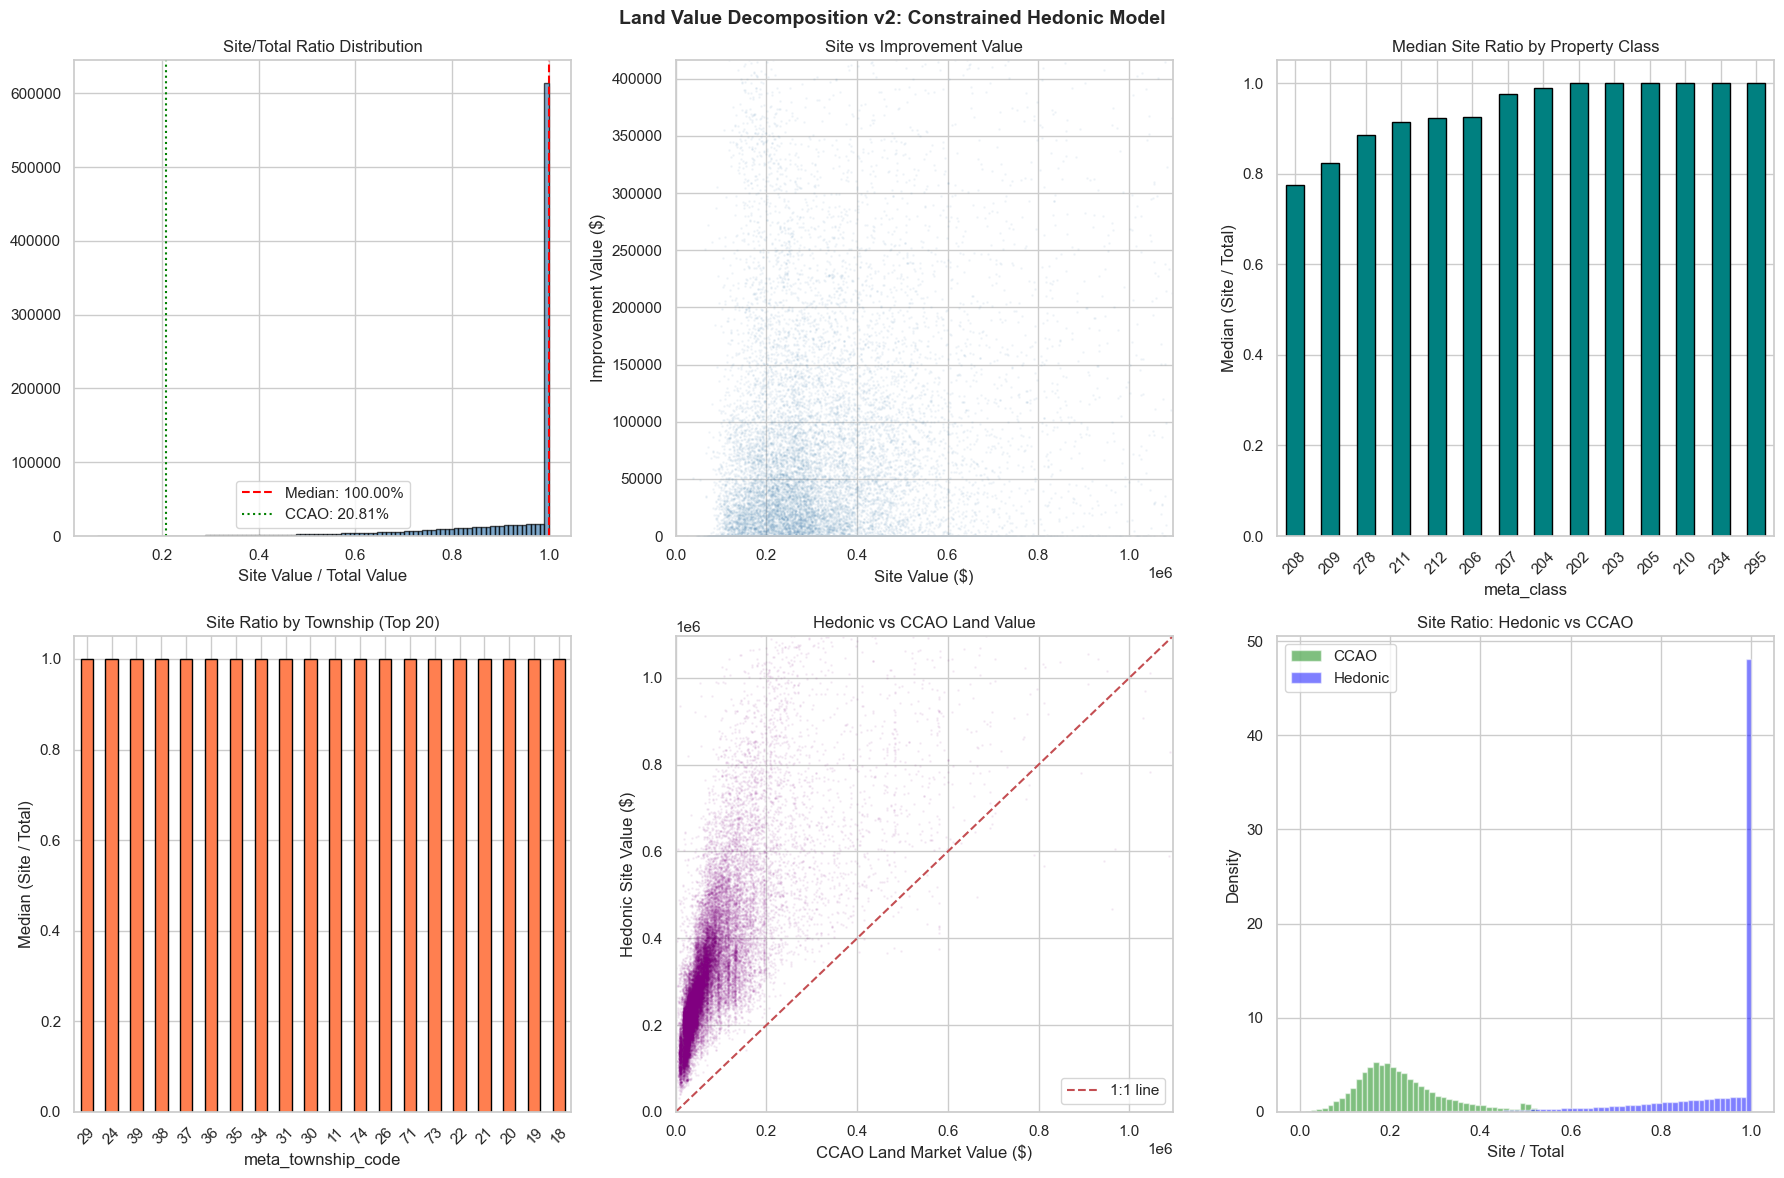

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# 1. Site ratio distribution
ax = axes[0, 0]
valid = assessment["site_value_ratio"].dropna()
ax.hist(valid, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(valid.median(), color="red", linestyle="--",
           label=f"Median: {valid.median():.2%}")
if LAND_AV_COL:
    ax.axvline(ccao_site_ratio_mv.median(), color="green", linestyle=":",
               label=f"CCAO: {ccao_site_ratio_mv.median():.2%}")
ax.set_title("Site/Total Ratio Distribution")
ax.set_xlabel("Site Value / Total Value")
ax.legend()
# 2. Site vs improvement scatter
ax = axes[0, 1]
sample = assessment.sample(min(30000, len(assessment)), random_state=42)
ax.scatter(sample["pred_site_value_adj"], sample["pred_improvement_value"],
           alpha=0.05, s=1, color="steelblue")
ax.set_xlabel("Site Value ($)")
ax.set_ylabel("Improvement Value ($)")
ax.set_title("Site vs Improvement Value")
ax.set_xlim(0, sample["pred_site_value_adj"].quantile(0.99))
ax.set_ylim(0, sample["pred_improvement_value"].quantile(0.99))
# 3. By property class
ax = axes[0, 2]
class_ratios = assessment.groupby(CLASS_COL)["site_value_ratio"].median().sort_values()
class_ratios.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.set_title("Median Site Ratio by Property Class")
ax.set_ylabel("Median (Site / Total)")
ax.tick_params(axis="x", rotation=45)
# 4. By township
ax = axes[1, 0]
if "meta_township_code" in assessment.columns:
    twp_ratios = (assessment.groupby("meta_township_code")["site_value_ratio"]
                  .median().sort_values(ascending=False))
    twp_ratios.head(20).plot(kind="bar", ax=ax, color="coral", edgecolor="black")
    ax.set_title("Site Ratio by Township (Top 20)")
    ax.set_ylabel("Median (Site / Total)")
    ax.tick_params(axis="x", rotation=45)
# 5. Hedonic vs CCAO scatter (validation)
ax = axes[1, 1]
if LAND_AV_COL:
    sample_idx = np.random.choice(len(assessment), min(30000, len(assessment)), replace=False)
    ax.scatter(ccao_land_mv.iloc[sample_idx], 
               assessment["pred_site_value_adj"].iloc[sample_idx],
               alpha=0.05, s=1, color="purple")
    lim = max(ccao_land_mv.quantile(0.99), 
              assessment["pred_site_value_adj"].quantile(0.99))
    ax.plot([0, lim], [0, lim], "r--", label="1:1 line")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("CCAO Land Market Value ($)")
    ax.set_ylabel("Hedonic Site Value ($)")
    ax.set_title("Hedonic vs CCAO Land Value")
    ax.legend()
# 6. Ratio comparison: hedonic vs CCAO
ax = axes[1, 2]
if LAND_AV_COL:
    ax.hist(ccao_site_ratio_mv.dropna().clip(0,1), bins=80, alpha=0.5, 
            label="CCAO", color="green", density=True)
    ax.hist(assessment["site_value_ratio"].dropna(), bins=80, alpha=0.5,
            label="Hedonic", color="blue", density=True)
    ax.set_title("Site Ratio: Hedonic vs CCAO")
    ax.set_xlabel("Site / Total")
    ax.set_ylabel("Density")
    ax.legend()
plt.suptitle("Land Value Decomposition v2: Constrained Hedonic Model",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/04v2_final_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Feature Importance for Selected Land Model

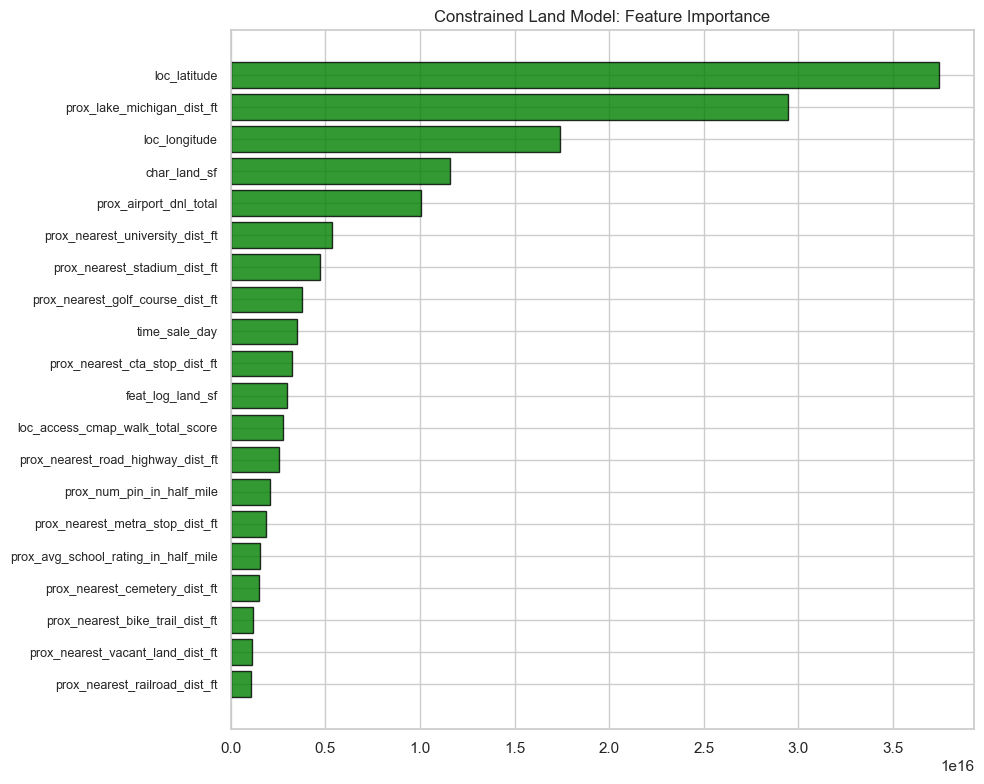

In [61]:
selected_model = models[[k for k in models.keys() 
                          if best_tier.replace("pred_site_", "") in 
                          k.replace(":", "").replace(" ", "_").replace("+", "plus")][0]]
land_importance = pd.DataFrame({
    "feature": selected_model.feature_name(),
    "gain": selected_model.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(land_importance))
top = land_importance.head(top_n)
ax.barh(range(top_n), top["gain"].values, color="green", edgecolor="black", alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top["feature"].values, fontsize=9)
ax.set_title("Constrained Land Model: Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/04v2_land_model_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Save Results

In [62]:
# Save decomposed assessment data
output_cols = [
    "meta_pin", CLASS_COL, "meta_township_code", "meta_nbhd_code",
    "char_land_sf", "char_bldg_sf",
    "pred_total_value", "pred_site_value_adj", "pred_improvement_value",
    "site_value_ratio",
]
# Add CCAO benchmark columns if available
if LAND_AV_COL:
    output_cols += [LAND_AV_COL, BLDG_AV_COL, "ccao_land_ratio"]
output_cols = [c for c in output_cols if c in assessment.columns]
assessment[output_cols].to_parquet(
    "../data/processed/assessment_decomposed.parquet", index=False
)
# Save selected land model
best_model_key = [k for k in models.keys() 
                  if best_tier.replace("pred_site_", "") in 
                  k.replace(":", "").replace(" ", "_").replace("+", "plus")][0]
models[best_model_key].save_model("../outputs/models/lgb_land_model_v2.txt")
# Save tier comparison for the report
tier_summary = {}
for site_col in site_cols:
    tier_label = site_col.replace("pred_site_", "")
    ratio = assessment[site_col] / assessment["pred_total_value"].replace(0, np.nan)
    ratio = ratio.clip(0, 1).dropna()
    tier_summary[tier_label] = {
        "median_ratio": float(ratio.median()),
        "mean_ratio": float(ratio.mean()),
        "std_ratio": float(ratio.std()),
        "iqr": float(ratio.quantile(0.75) - ratio.quantile(0.25)),
    }
import json as json_mod
with open("../outputs/reports/tier_comparison.json", "w") as f:
    json_mod.dump(tier_summary, f, indent=2)
print("Saved: ../data/processed/assessment_decomposed.parquet")
print("Saved: ../outputs/models/lgb_land_model_v2.txt")
print("Saved: ../outputs/reports/tier_comparison.json")

Saved: ../data/processed/assessment_decomposed.parquet
Saved: ../outputs/models/lgb_land_model_v2.txt
Saved: ../outputs/reports/tier_comparison.json
